# Sales Data Analysis

## 1. Data Understanding

### Preview of the Dataset

In [1]:
import pandas as pd

df = pd.read_csv("../data/sales_data.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


### Observation

The first five rows provide an overview of the dataset structure.

The dataset contains 18 columns related to:
- Order information
- Shipping information
- Customer information
- Geographic information
- Product information
- Sales

### Dataset Size

In [2]:
df.shape

(9800, 18)

The dataset contains 9,800 rows and 18 columns.

### Column Names

In [3]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

### Data Types

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

Shows the data type of each column and basic dataset information.

### Summary Statistics

In [5]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


Provides descriptive statistics for numerical columns.

## 2. Data Profiling

## 2.1 Missing Values

Goal:
Identify missing values before applying any cleaning operations.

In [6]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

### Observation

Only the Postal Code column contains 11 missing values.

### Decision

The missing values will not be removed at this stage because they represent a very small portion of the dataset and do not affect the main analysis.

## 2.2 Duplicate Records

The dataset is checked for duplicate records to ensure that no identical rows could bias the analysis.

In [7]:
df.duplicated().sum()

np.int64(0)

### Observation

No duplicate rows were found in the dataset.

### Decision

Since no fully duplicated rows were detected, no duplicate records were removed.

## 2.3 Data Types

Goal: Review the data types of each column and identify any columns with inappropriate data types before cleaning.

In [8]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

### Observation

- Most columns are stored as the **object** data type.
- **Row ID** is stored as **int64**.
- **Sales** and **Postal Code** are stored as **float64**.
- **Order Date** and **Ship Date** are currently stored as **object**, although they represent dates.

### Decision

The **Order Date** and **Ship Date** columns should be converted to the **datetime** data type during the Data Cleaning stage.

## 2.4 Inconsistent Values

### Goal

Inspect categorical columns to identify inconsistent values such as differences in spelling, capitalization, or formatting.

In [9]:
df["Segment"].unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [10]:
df["Ship Mode"].unique()

array(['Second Class', 'Standard Class', 'First Class', 'Same Day'],
      dtype=object)

In [11]:
df["Category"].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [12]:
df["Region"].unique()

array(['South', 'West', 'Central', 'East'], dtype=object)

In [13]:
df["Sub-Category"].unique()

array(['Bookcases', 'Chairs', 'Labels', 'Tables', 'Storage',
       'Furnishings', 'Art', 'Phones', 'Binders', 'Appliances', 'Paper',
       'Accessories', 'Envelopes', 'Fasteners', 'Supplies', 'Machines',
       'Copiers'], dtype=object)

## 2.5 Numerical Data Validation

### Goal

Review the numerical columns to identify potential data quality issues such as invalid values and possible outliers.

In [14]:
df["Sales"].describe()

count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64

### Observation

- The Sales column contains no missing or negative values.
- The maximum sales value is significantly higher than the median.
- The large difference between the mean and median suggests the presence of potential outliers.

### Decision

Potential outliers will be investigated during the Exploratory Data Analysis (EDA) stage before deciding whether any treatment is necessary.

# 3. Data Cleaning

## 3.1 Handle Missing Values

### Goal

Handle missing values while preserving as much useful information as possible.Only 11 missing values were found in the Postal Code column.The missing Postal Code values will be kept as NaN because they represent a very small portion of the dataset and imputing artificial values could reduce data quality.

## 3.2 Convert Data Types   

### Goal

Convert columns to their appropriate data types to enable accurate analysis and calculations.

In [15]:
df_clean = df.copy()

df_clean["Order Date"] = pd.to_datetime(
    df_clean["Order Date"],
    dayfirst=True
)

df_clean["Ship Date"] = pd.to_datetime(
    df_clean["Ship Date"],
    dayfirst=True
)

In [16]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

### Observation

The Order Date and Ship Date columns were successfully converted from the **object** data type to datetime64[ns].

## 3.3 Date Validation

### Goal

Validate the date columns to ensure the chronological order of the records is correct.

In [17]:
(df_clean["Ship Date"] < df_clean["Order Date"]).sum()

np.int64(0)

### Observation

No records were found where the Ship Date occurs before the Order Date.

### Decision

The chronological order of the date columns is valid, and no correction is required.

## 3.4 Standardization

### Observation

The inspected categorical columns were already standardized. No inconsistencies in spelling, capitalization, or formatting were found.


### Decision
No standardization was required.

# 4. Business Questions

The objective of this analysis is to answer the following business questions:

1. Which product category generates the highest sales?
2. Which region generates the highest sales?
3. Which customer segment contributes the most to total sales?
4. Which product categories perform best in each region?
5. Which customer segment generates the highest sales within each product category?
6. How do sales change over time?
7. Which products generate the highest revenue?

# 5. Exploratory Data Analysis

## 5.1 Sales by Product Category

### Goal

Analyze total sales across different product categories to identify which category generates the highest revenue.

In [18]:
category_sales=(df_clean.groupby("Category")["Sales"].sum().sort_values(ascending=False))

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

### Observation

Technology generated the highest total sales, followed by Furniture and Office Supplies.
### Business Insight

Technology products are the primary revenue driver for the business, indicating strong customer demand in this category.

<Axes: title={'center': 'Total Sales by Product Category'}, xlabel='Category'>

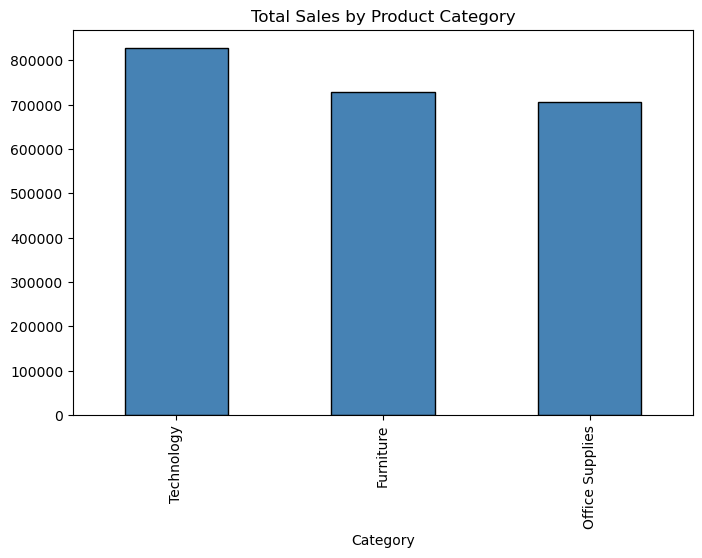

In [36]:
category_sales.plot(
    kind="bar",
    color="steelblue",
     edgecolor="black",
    figsize=(8, 5),
    title="Total Sales by Product Category"
    
)

## 5.2 Sales by Region

### Goal

Analyze total sales across different regions to identify which region generates the highest revenue.

In [20]:
region_sales = (
    df_clean.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

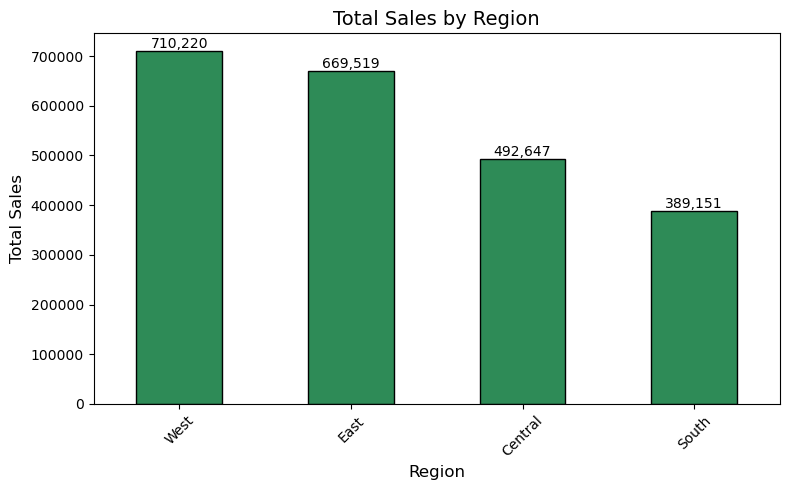

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

ax = region_sales.plot(
    kind="bar",
    color="seagreen",
    edgecolor="black"
)

plt.title("Total Sales by Region", fontsize=14)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.xticks(rotation=45)

# نمایش مقدار روی هر میله
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        f'{height:,.0f}',
        (bar.get_x() + bar.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Observation

The West region generated the highest total sales, while the South region generated the lowest.

### Business Insight

The West region is the strongest market for the company and contributes the largest share of total revenue.

### Recommendation

The company should continue investing in the West region while developing strategies to improve sales in the South region.

## 5.3 Sales by Customer Segment

### Goal

Analyze total sales across different customer segments to identify which segment contributes the most to total sales.

customer_segment_sales = (
    df_clean.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

customer_segment_sales

In [22]:
customer_segment_sales = (
    df_clean.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

customer_segment_sales

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64

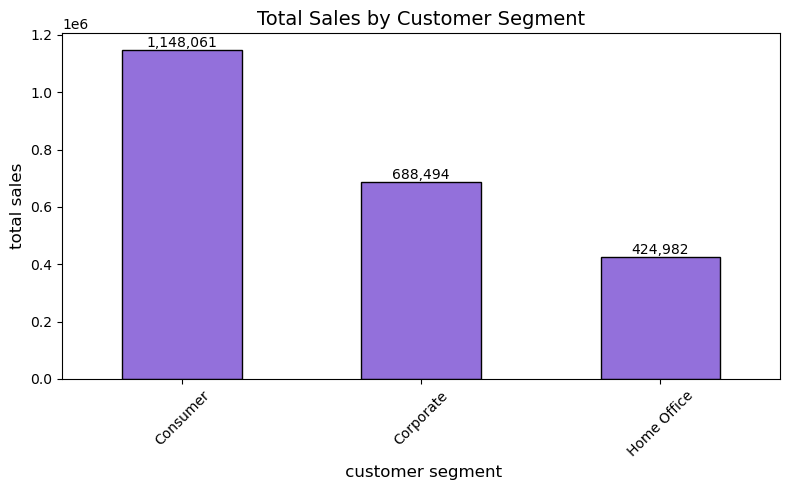

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

ax=customer_segment_sales.plot(
    kind="bar",
    color="mediumpurple",
    edgecolor="black"
)

plt.title("Total Sales by Customer Segment", fontsize=14)
plt.xlabel(" customer segment", fontsize=12)
plt.ylabel("total sales", fontsize=12)
plt.xticks(rotation=45)

for bar in ax.patches:
    height=bar.get_height()
    ax.annotate(
        f'{height:,.0f}',
        (bar.get_x()+bar.get_width()/2,height),
        ha='center',
        va='bottom',
        fontsize=10
    )
plt.tight_layout()
plt.show()


### Observation

The Consumer segment generated the highest total sales, followed by the Corporate segment. The Home Office segment generated the lowest total sales.
### Business Insight

The Consumer segment is the company's primary source of revenue, indicating that individual consumers represent the largest customer base and purchasing power.
### Recommendation

The company should continue focusing on the Consumer segment while exploring strategies to increase sales in the Corporate and Home Office segments.


## 5.4 Customer Segment within Each Product Category

### Goal

Analyze sales across customer segments within each product category to identify the highest-contributing segment for each category.

In [24]:
category_segment_sales = (
    df_clean.groupby(["Category", "Segment"])["Sales"]
    .sum()
    .unstack()
)

category_segment_sales

Segment,Consumer,Corporate,Home Office
Category,,,
Furniture,387696.258,220321.7018,120640.6159
Office Supplies,359352.608,224130.5360,121939.1900
Technology,401011.665,244041.8370,182402.3710


<Figure size 1000x600 with 0 Axes>

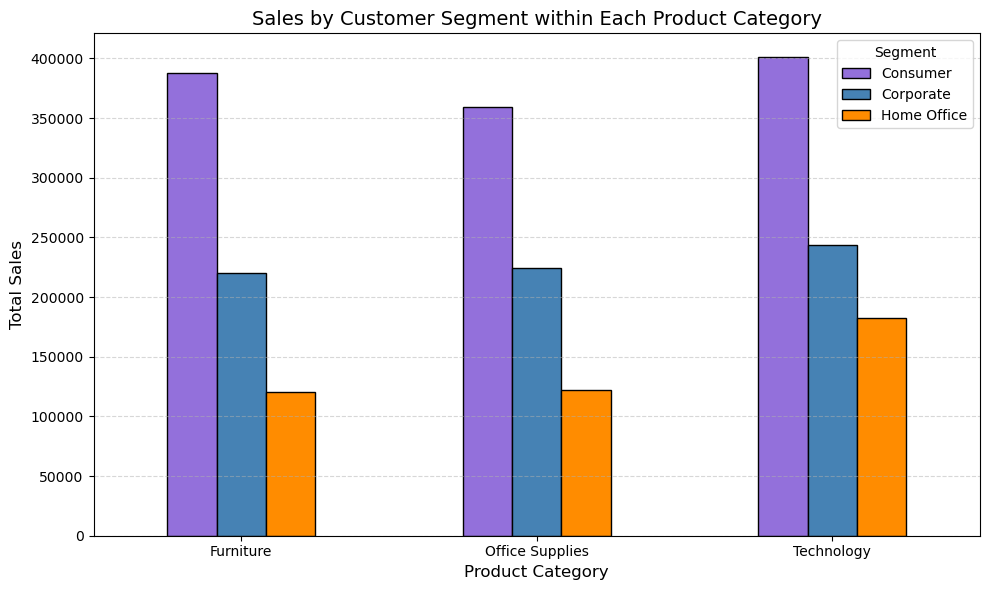

In [25]:
import matplotlib.pyplot as plt

category_segment_sales = (
    df_clean.groupby(["Category", "Segment"])["Sales"]
    .sum()
    .unstack()
)

plt.figure(figsize=(10,6))

ax = category_segment_sales.plot(
    kind="bar",
    figsize=(10,6),
    edgecolor="black",
    color=["mediumpurple", "steelblue", "darkorange"]
)

plt.title("Sales by Customer Segment within Each Product Category", fontsize=14)
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Observation

The Consumer segment generated the highest sales across all product categories, followed by the Corporate segment. The Home Office segment consistently recorded the lowest sales. Additionally, Technology was the highest-performing category across all customer segments.
### Business Insight

Consumer customers represent the company's primary source of revenue across all product categories. Technology products are particularly popular among all customer segments, indicating strong and consistent market demand.
### Recommendation

The company should continue focusing on Consumer customers while expanding marketing efforts toward Corporate and Home Office segments. It should also maintain investment in the Technology category due to its consistently strong performance.

## 5.5 Product Categories by Region

### Goal

Analyze total sales for each product category across different regions to identify the best-performing category in each region.

In [26]:
category_region_sales = (
    df_clean.groupby(["Region", "Category"])["Sales"]
    .sum()
    .unstack()
)

category_region_sales

Category,Furniture,Office Supplies,Technology
Region,,,
Central,160317.4622,163590.243,168739.208
East,206461.3880,199940.811,263116.527
South,116531.4800,124424.771,148195.208
West,245348.2455,217466.509,247404.930


<Figure size 1400x700 with 0 Axes>

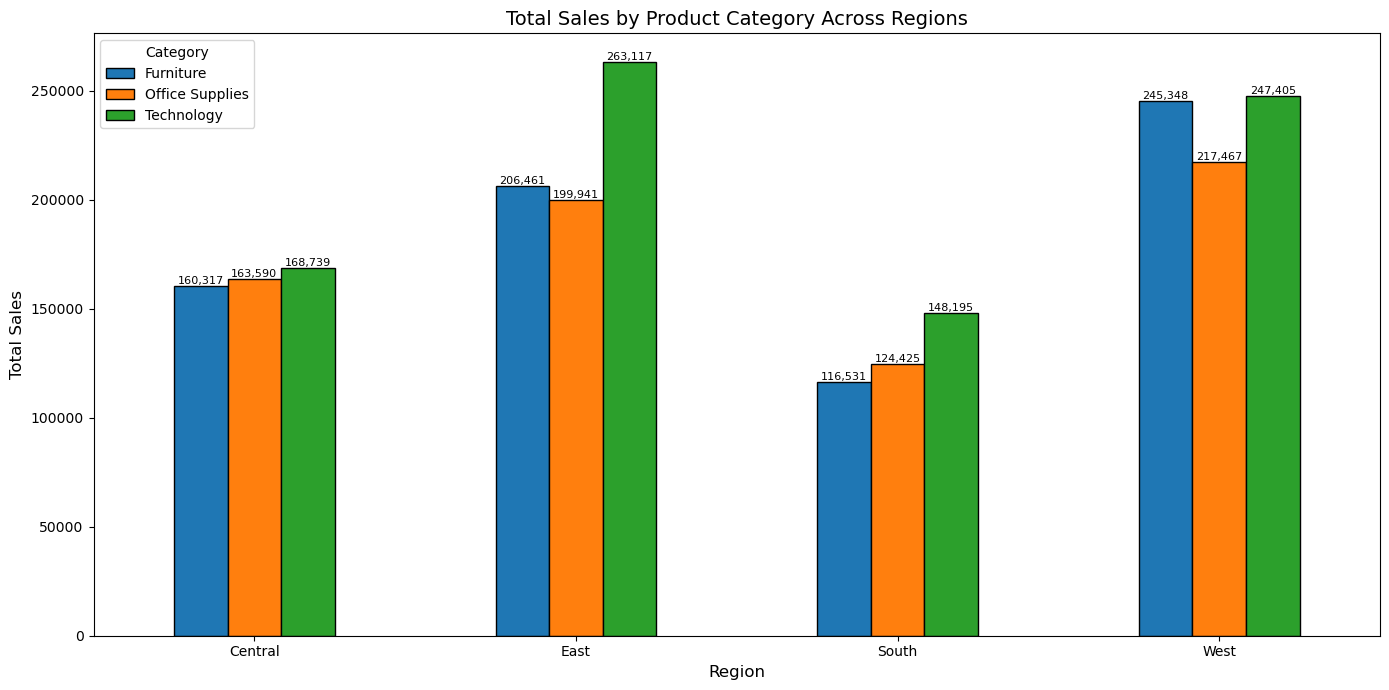

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

ax = category_region_sales.plot(
    kind="bar",
    figsize=(14,7),
    edgecolor="black"
)

plt.title("Total Sales by Product Category Across Regions", fontsize=14)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.xticks(rotation=0)

for bar in ax.patches:
    height = bar.get_height()

    ax.annotate(
        f'{height:,.0f}',
        (bar.get_x() + bar.get_width()/2, height),
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.show()

### Observation

Technology generated the highest sales in all four regions. Furniture ranked second in the East and West regions, while Office Supplies slightly outperformed Furniture in the Central and South regions.
### Business Insight

Technology products consistently perform well across all regions, indicating strong customer demand regardless of location.
### Recommendation

The company should continue investing in the Technology category across all regions while evaluating strategies to improve the performance of Furniture and Office Supplies, especially in the South region.

## 5.6 Sales Trend Over Time

### Goal

Analyze sales over time to identify trends, seasonal patterns, and changes in revenue.

In [28]:
df_clean["YearMonth"] = df_clean["Order Date"].dt.to_period("M")

In [29]:
df_clean[["Order Date", "YearMonth"]].head()

,Order Date,YearMonth
0,2017-11-08,2017-11
1,2017-11-08,2017-11
2,2017-06-12,2017-06
3,2016-10-11,2016-10
4,2016-10-11,2016-10


In [30]:
monthly_sales = (
    df_clean.groupby("YearMonth")["Sales"]
    .sum()
)

monthly_sales

YearMonth
2015-01     14205.7070
2015-02      4519.8920
2015-03     55205.7970
2015-04     27906.8550
2015-05     23644.3030
2015-06     34322.9356
2015-07     33781.5430
2015-08     27117.5365
2015-09     81623.5268
2015-10     31453.3930
2015-11     77907.6607
2015-12     68167.0585
2016-01     18066.9576
2016-02     11951.4110
2016-03     32339.3184
2016-04     34154.4685
2016-05     29959.5305
2016-06     23599.3740
2016-07     28608.2590
2016-08     36818.3422
2016-09     63133.6060
2016-10     31011.7375
2016-11     75249.3995
2016-12     74543.6012
2017-01     18542.4910
2017-02     22978.8150
2017-03     51165.0590
2017-04     38679.7670
2017-05     56656.9080
2017-06     39724.4860
2017-07     38320.7830
2017-08     30542.2003
2017-09     69193.3909
2017-10     59583.0330
2017-11     79066.4958
2017-12     95739.1210
2018-01     43476.4740
2018-02     19920.9974
2018-03     58863.4128
2018-04     35541.9101
2018-05     43825.9822
2018-06     48190.7277
2018-07     44825.1040
2

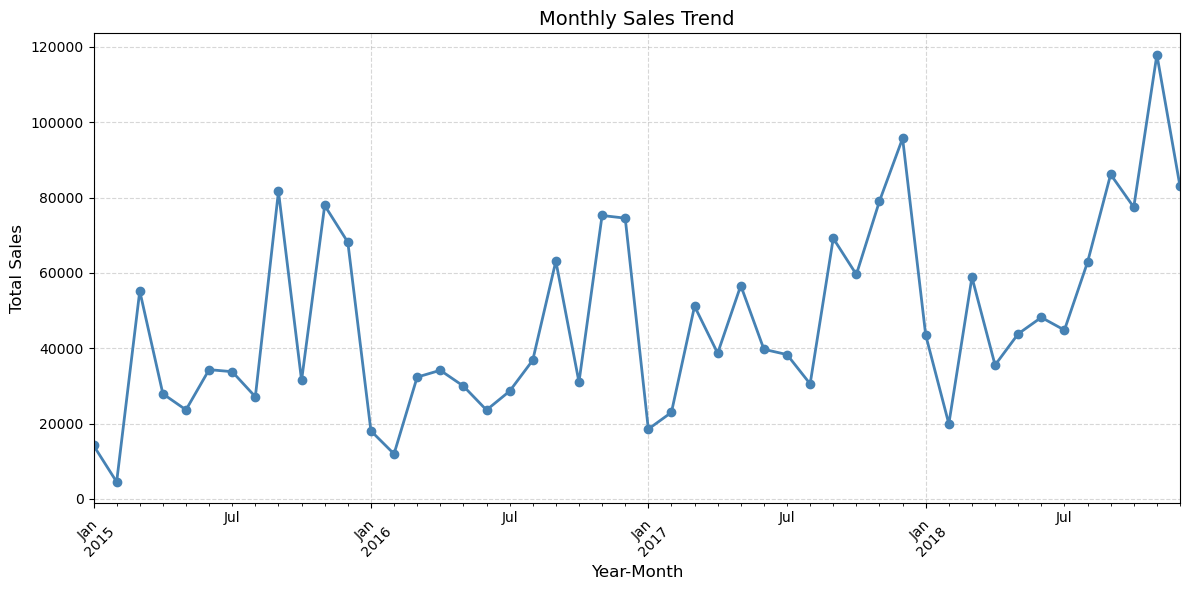

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

ax = monthly_sales.plot(
    kind="line",
    color="steelblue",
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend", fontsize=14)
plt.xlabel("Year-Month", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Business Insight

The company has experienced overall business growth over the observed period, despite short-term fluctuations in monthly sales.
### Recommendation

The company should investigate the factors behind sales peaks and declines to better understand customer purchasing behavior and maintain long-term growth.

## 5.7 Top Products by Revenue

### Goal

Analyze product sales to identify the highest-revenue products.

In [32]:
top_products=(
    df_clean.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
)
top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

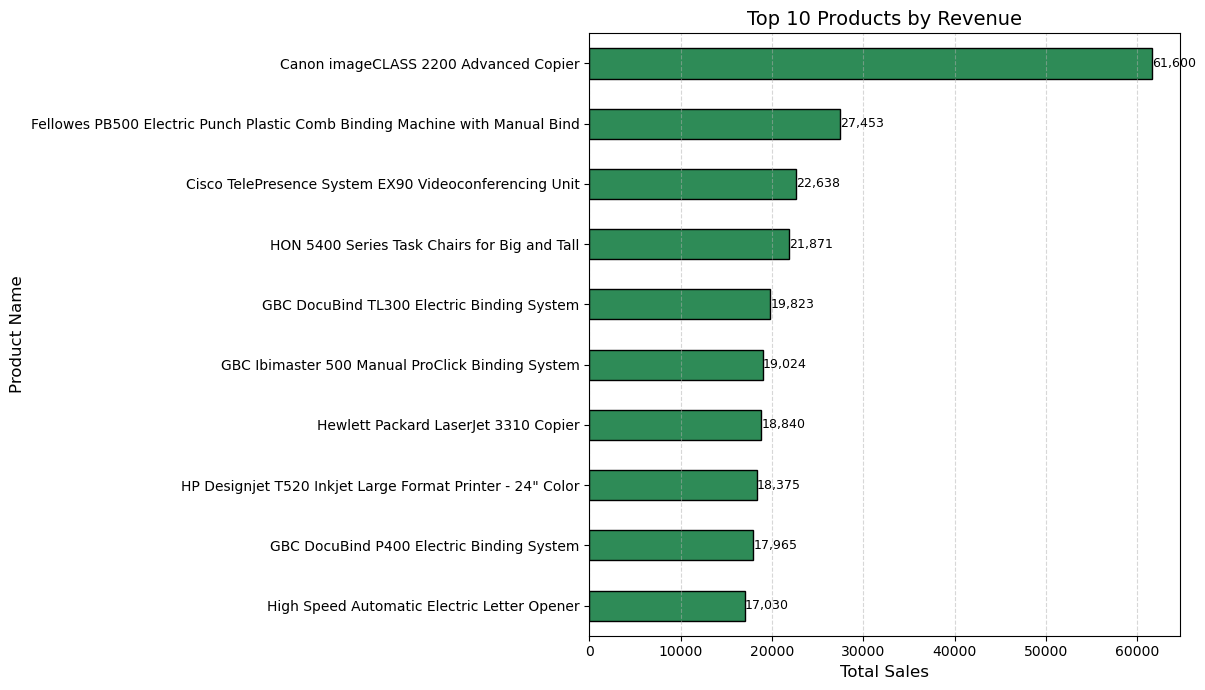

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))

ax = top_products.plot(
    kind="barh",
    color="seagreen",
    edgecolor="black"
)

plt.title("Top 10 Products by Revenue", fontsize=14)
plt.xlabel("Total Sales", fontsize=12)
plt.ylabel("Product Name", fontsize=12)

for bar in ax.patches:
    width = bar.get_width()

    ax.annotate(
        f'{width:,.0f}',
        (width, bar.get_y() + bar.get_height()/2),
        ha='left',
        va='center',
        fontsize=9
    )

ax.invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()